# Matemática Financeira Aplicada

Módulo extra, fora da trilha principal Estatística → Econometria — fundamentos de
matemática financeira em Python: juros, taxas equivalentes, séries de pagamentos,
avaliação de investimentos (VPL/TIR) e sistemas de amortização.

Pré-requisito: [Módulo 00 — Python Essencial](../00_Python_Essencial)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf

plt.rcParams.update({'font.size': 12})

def fmt_brl(valor):
    """Formata número no padrão brasileiro: ponto como milhar, vírgula como decimal."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

## 1. Juros simples x juros compostos

No regime **simples**, os juros incidem sempre sobre o capital inicial:
$M = C(1 + i \cdot n)$. No regime **composto** (o padrão no mercado financeiro), os
juros incidem sobre o saldo já acrescido de juros anteriores — "juros sobre juros":
$M = C(1 + i)^n$.

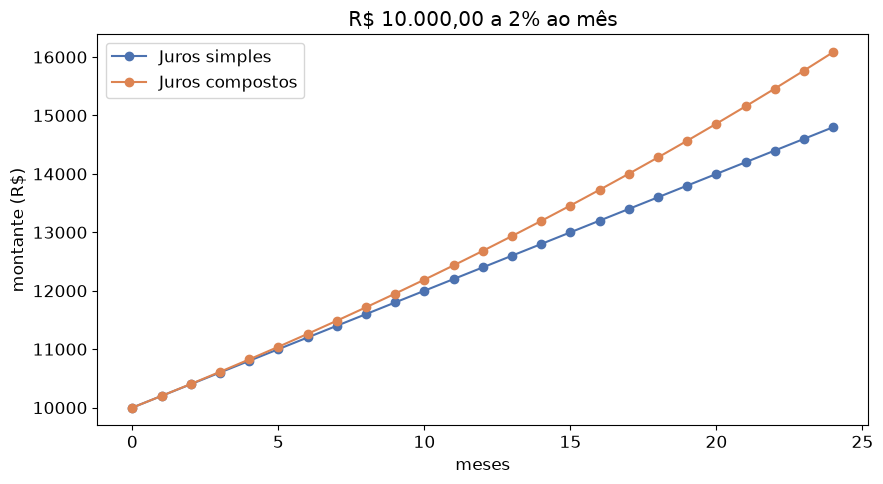

Após 24 meses -- simples: R$ 14.800,00   composto: R$ 16.084,37


In [2]:
capital = 10_000
taxa_mensal = 0.02
meses = np.arange(0, 25)

montante_simples = capital * (1 + taxa_mensal * meses)
montante_composto = capital * (1 + taxa_mensal) ** meses

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(meses, montante_simples, marker='o', label='Juros simples', color='#4C72B0')
ax.plot(meses, montante_composto, marker='o', label='Juros compostos', color='#DD8452')
ax.set_title(f'{fmt_brl(capital)} a {taxa_mensal:.0%} ao mês')
ax.set_xlabel('meses')
ax.set_ylabel('montante (R$)')
ax.legend()
plt.tight_layout()
plt.savefig('img_juros_simples_x_compostos.png', dpi=110)
plt.show()

print(f"Após 24 meses -- simples: {fmt_brl(montante_simples[24])}   composto: {fmt_brl(montante_composto[24])}")

## 2. Taxas equivalentes: nominal x efetiva

Uma taxa **nominal** anual capitalizada mensalmente não é simplesmente dividida por 12
para virar mensal, e não é a taxa efetiva anual — a capitalização composta dentro do
período muda o resultado:

$$i_{efetiva} = \left(1 + \frac{i_{nominal}}{m}\right)^m - 1$$

onde $m$ é o número de capitalizações no período.

In [3]:
taxa_nominal_anual = 0.12
capitalizacoes_por_ano = 12

taxa_mensal_proporcional = taxa_nominal_anual / capitalizacoes_por_ano
taxa_efetiva_anual = (1 + taxa_mensal_proporcional) ** capitalizacoes_por_ano - 1

print(f"Taxa nominal anual:            {taxa_nominal_anual:.2%}")
print(f"Taxa mensal proporcional:      {taxa_mensal_proporcional:.4%}")
print(f"Taxa efetiva anual (composta): {taxa_efetiva_anual:.4%}")
print(f"\nA taxa efetiva é maior que a nominal -- a diferença é o efeito dos juros")
print("compostos capitalizando 12 vezes dentro do ano.")

Taxa nominal anual:            12.00%
Taxa mensal proporcional:      1.0000%
Taxa efetiva anual (composta): 12.6825%

A taxa efetiva é maior que a nominal -- a diferença é o efeito dos juros
compostos capitalizando 12 vezes dentro do ano.


## 3. Séries de pagamentos uniformes

O valor presente de uma série de $n$ pagamentos iguais (`PMT`), a uma taxa $i$ por
período:

$$PV = PMT \cdot \frac{(1+i)^n - 1}{i(1+i)^n}$$

### Exemplo — financiamento imobiliário

Um imóvel é oferecido com entrada de R\$ 250.000 mais 84 parcelas mensais de R\$
9.200. Qual seria o valor equivalente à vista, descontando a uma taxa de 1,2% ao mês?

In [4]:
entrada = 250_000
parcela = 9_200
n_parcelas = 84
taxa_mensal_fin = 0.012

valor_presente_parcelas = npf.pv(taxa_mensal_fin, n_parcelas, -parcela)
valor_a_vista_equivalente = entrada + valor_presente_parcelas

print(f"Valor presente das parcelas: {fmt_brl(valor_presente_parcelas)}")
print(f"Valor à vista equivalente (entrada + parcelas): {fmt_brl(valor_a_vista_equivalente)}")

Valor presente das parcelas: R$ 485.189,27
Valor à vista equivalente (entrada + parcelas): R$ 735.189,27


## 4. VPL e TIR — avaliando investimentos

O **Valor Presente Líquido** traz todos os fluxos de caixa de um investimento para o
presente, a uma taxa mínima de atratividade (TMA):

$$VPL = \sum_{t=0}^{n} \frac{F_t}{(1+i)^t}$$

A **Taxa Interna de Retorno** é a taxa que zera o VPL — a rentabilidade "embutida" no
fluxo de caixa. Um projeto é viável quando $VPL > 0$ (equivalentemente, quando
$TIR > TMA$).

### Exemplo — comparando dois investimentos

Com uma TMA de 7,5% ao ano, qual dos dois investimentos abaixo é o melhor?
- **A**: investe R\$ 1.000.000 hoje, recebe R\$ 1.250.984,23 em 3 anos (um único
  resgate no final).
- **B**: investe R\$ 1.000.000 hoje, recebe R\$ 850.000 em 1 ano e mais
  R\$ 248.400 em 2 anos.

In [5]:
tma = 0.075

fluxo_a = [-1_000_000, 0, 0, 1_250_984.23]
fluxo_b = [-1_000_000, 850_000, 248_400]

vpl_a, tir_a = npf.npv(tma, fluxo_a), npf.irr(fluxo_a)
vpl_b, tir_b = npf.npv(tma, fluxo_b), npf.irr(fluxo_b)

print(f"Investimento A -- VPL: {fmt_brl(vpl_a)}   TIR: {tir_a:.2%}")
print(f"Investimento B -- VPL: {fmt_brl(vpl_b)}   TIR: {tir_b:.2%}")

Investimento A -- VPL: R$ 6.992,98   TIR: 7.75%
Investimento B -- VPL: R$ 5.646,30   TIR: 8.00%


Repare a **inconsistência de ranking**: o investimento B tem a maior TIR (8,00% x
7,75%), mas o investimento A tem o maior VPL. Isso pode acontecer quando os fluxos têm
tamanho ou momento diferentes -- a TIR mede uma taxa (%), o VPL mede um valor (R\$). Para
decisões de investimento (especialmente projetos mutuamente exclusivos), a literatura de
finanças recomenda priorizar o **VPL** exatamente por esse motivo: ele responde
diretamente "quanto valor este projeto cria", enquanto a TIR pode enganar quando os
projetos têm escalas diferentes.

## 5. Sistemas de amortização: SAC x Price

Nos dois sistemas, o saldo devedor é amortizado ao longo de $n$ parcelas com juros $i$
por período -- a diferença está em como a prestação é estruturada:

- **SAC** (Sistema de Amortização Constante): a parcela de **amortização** é sempre a
  mesma (`principal / n`); como o saldo devedor cai a cada mês, os juros diminuem, e a
  prestação total **decresce** ao longo do tempo.
- **Price** (Sistema Francês): a **prestação total** é constante do início ao fim; a
  composição interna (juros x amortização) muda mês a mês.

### Exemplo — financiamento de R$ 750.000 em 90 meses a 1,75% ao mês

In [6]:
principal = 750_000
n_meses = 90
taxa_am = 0.0175

# --- SAC ---
amortizacao_sac = principal / n_meses
saldo = principal
linhas_sac = []
for mes in range(1, n_meses + 1):
    juros = saldo * taxa_am
    prestacao = amortizacao_sac + juros
    saldo -= amortizacao_sac
    linhas_sac.append({'mes': mes, 'prestacao': prestacao, 'juros': juros,
                        'amortizacao': amortizacao_sac, 'saldo': saldo})
sac = pd.DataFrame(linhas_sac)

# --- Price ---
pmt_price = -npf.pmt(taxa_am, n_meses, principal)
saldo = principal
linhas_price = []
for mes in range(1, n_meses + 1):
    juros = saldo * taxa_am
    amortizacao = pmt_price - juros
    saldo -= amortizacao
    linhas_price.append({'mes': mes, 'prestacao': pmt_price, 'juros': juros,
                          'amortizacao': amortizacao, 'saldo': saldo})
price = pd.DataFrame(linhas_price)

print("SAC -- prestação do mês 54:")
print(sac.loc[sac['mes'] == 54].to_string(index=False))
print("\nPrice -- prestação constante:")
print(fmt_brl(pmt_price))

SAC -- prestação do mês 54:
 mes    prestacao       juros  amortizacao    saldo
  54 13729.166667 5395.833333  8333.333333 300000.0

Price -- prestação constante:
R$ 16.610,70


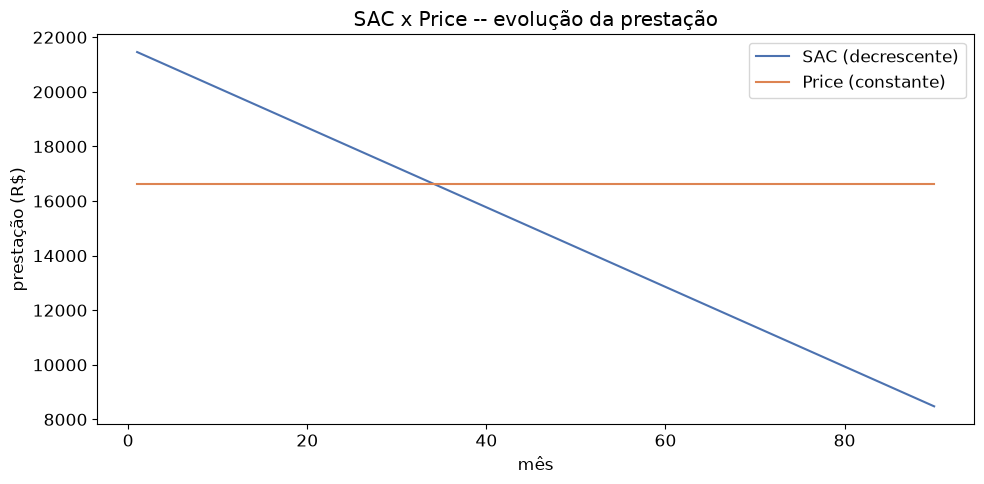

Total pago -- SAC: R$ 1.347.187,50   Price: R$ 1.494.963,29
SAC paga R$ 147.775,79 a menos ao final
(SAC amortiza mais rápido no início, reduzindo o saldo sobre o qual os juros incidem)


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sac['mes'], sac['prestacao'], label='SAC (decrescente)', color='#4C72B0')
ax.plot(price['mes'], price['prestacao'], label='Price (constante)', color='#DD8452')
ax.set_title('SAC x Price -- evolução da prestação')
ax.set_xlabel('mês')
ax.set_ylabel('prestação (R$)')
ax.legend()
plt.tight_layout()
plt.savefig('img_sac_x_price.png', dpi=110)
plt.show()

total_pago_sac = sac['prestacao'].sum()
total_pago_price = price['prestacao'].sum()
print(f"Total pago -- SAC: {fmt_brl(total_pago_sac)}   Price: {fmt_brl(total_pago_price)}")
print(f"SAC paga {fmt_brl(total_pago_price - total_pago_sac)} a menos ao final")
print("(SAC amortiza mais rápido no início, reduzindo o saldo sobre o qual os juros incidem)")

## 6. Payback simples e descontado

O período de payback é o tempo necessário para o fluxo de caixa acumulado de um
investimento se tornar positivo. O **payback descontado** faz a mesma conta, mas
trazendo cada fluxo a valor presente antes de acumular -- mais rigoroso, pois reconhece
o custo de oportunidade do dinheiro no tempo.

In [8]:
fluxo = [-500_000, 150_000, 180_000, 200_000, 220_000, 180_000]
taxa_desconto = 0.10

acumulado_simples = np.cumsum(fluxo)
fluxo_descontado = [f / (1 + taxa_desconto) ** t for t, f in enumerate(fluxo)]
acumulado_descontado = np.cumsum(fluxo_descontado)

tabela_payback = pd.DataFrame({
    'ano': range(len(fluxo)),
    'fluxo': fluxo,
    'acumulado_simples': acumulado_simples,
    'fluxo_descontado': np.round(fluxo_descontado, 2),
    'acumulado_descontado': np.round(acumulado_descontado, 2),
})
print(tabela_payback)

payback_simples = np.argmax(acumulado_simples >= 0)
payback_descontado = np.argmax(acumulado_descontado >= 0)
print(f"\nPayback simples: entre os anos {payback_simples-1} e {payback_simples}")
print(f"Payback descontado: entre os anos {payback_descontado-1} e {payback_descontado}")
print("(o descontado sempre vem depois ou igual ao simples -- descontar reduz o peso")
print("dos fluxos futuros, atrasando o momento em que o acumulado vira positivo)")

   ano   fluxo  acumulado_simples  fluxo_descontado  acumulado_descontado
0    0 -500000            -500000        -500000.00            -500000.00
1    1  150000            -350000         136363.64            -363636.36
2    2  180000            -170000         148760.33            -214876.03
3    3  200000              30000         150262.96             -64613.07
4    4  220000             250000         150262.96              85649.89
5    5  180000             430000         111765.84             197415.73

Payback simples: entre os anos 2 e 3
Payback descontado: entre os anos 3 e 4
(o descontado sempre vem depois ou igual ao simples -- descontar reduz o peso
dos fluxos futuros, atrasando o momento em que o acumulado vira positivo)


## 7. Exercícios de fixação

1. Um título paga R\$ 1.000,00 no vencimento e é vendido hoje a R\$ 870,50, faltando
   180 dias úteis (considere ano de 252 dias úteis). Qual a taxa efetiva anual da
   aplicação?
2. Refaça a tabela SAC do exemplo da seção 5 para um empréstimo de R\$ 300.000 em 48
   meses a 1,3% ao mês. Qual o valor da 24ª prestação?

In [9]:
# 1.
valor_face, preco_hoje, dias_uteis = 1000, 870.50, 180
taxa_periodo = (valor_face / preco_hoje) - 1
taxa_efetiva_anual_1 = (1 + taxa_periodo) ** (252 / dias_uteis) - 1
print(f"1) Taxa efetiva anual: {taxa_efetiva_anual_1:.4%}")

# 2.
principal_2, n_2, taxa_2 = 300_000, 48, 0.013
amortizacao_2 = principal_2 / n_2
saldo_2 = principal_2
for mes in range(1, 25):
    juros_2 = saldo_2 * taxa_2
    prestacao_2 = amortizacao_2 + juros_2
    saldo_2 -= amortizacao_2
print(f"2) Prestação nº 24: {fmt_brl(prestacao_2)}")

1) Taxa efetiva anual: 21.4294%
2) Prestação nº 24: R$ 8.281,25


## Bibliografia
- ASSAF NETO, Alexandre. *Matemática Financeira e suas Aplicações*. 14. ed. São Paulo: Atlas, 2019.
- ROSS, Stephen A.; WESTERFIELD, Randolph W.; JORDAN, Bradford D. *Fundamentos de Administração Financeira*. 11. ed. Porto Alegre: AMGH, 2018.
- SAMANEZ, Carlos Patricio. *Matemática Financeira: Aplicações à Análise de Investimentos*. 5. ed. São Paulo: Pearson, 2010.